In [1]:
import numpy as np

In [6]:
np.random.uniform(-5, 45, (100000,1)).round(1)

array([[20.5],
       [30.4],
       [38.2],
       ...,
       [-2.7],
       [11.8],
       [35.5]], shape=(100000, 1))

In [7]:
import torch

In [11]:
url = "https://github.com/ageron/data/raw/main/ridership.tgz"

from pathlib import Path

download_dir = Path().resolve() / 'downloads'
download_dir.mkdir(exist_ok=True, parents=True)
download_file = download_dir / "ridership.tgz"

import urllib.request

urllib.request.urlretrieve(url, download_file)

(WindowsPath('C:/Users/user/Desktop/div/notebooks/downloads/ridership.tgz'),
 <http.client.HTTPMessage at 0x2525e0d17c0>)

In [ ]:
import tarfile

with tarfile.open(download_file) as f:
	f.extractall(path=download_dir, filter='data')

In [18]:
csv_dir = download_dir / 'ridership'
csv_path = next(csv_dir.glob('*.csv'))
csv_path

WindowsPath('C:/Users/user/Desktop/div/notebooks/downloads/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv')

In [19]:
import pandas as pd

In [46]:
df = pd.read_csv(csv_path, parse_dates=['service_date'])
df.columns = ['date', 'day_type', 'bus', 'rail', 'total']
df = df.drop('total', axis='columns')
df = df.drop_duplicates()
df = df.sort_values('date').set_index('date')
df

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065
2021-11-28,U,184817,147830


In [48]:
df['day_type'].value_counts()

day_type
W    5336
U    1216
A    1087
Name: count, dtype: int64

<Axes: xlabel='date'>

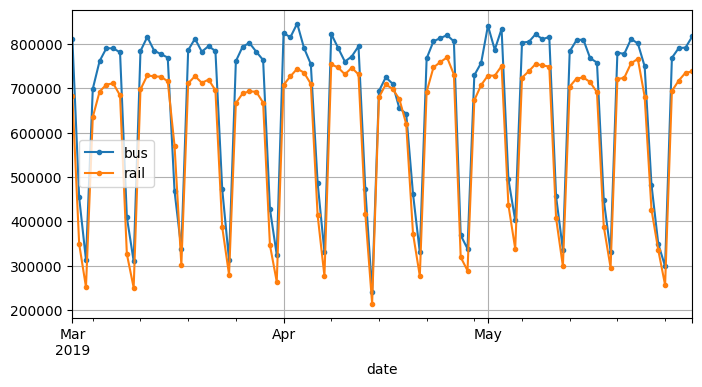

In [60]:
import matplotlib.pyplot as plt

df.loc['2019-03':'2019-05'].plot(grid=True, marker='.',figsize=(8,4))

<Axes: xlabel='date'>

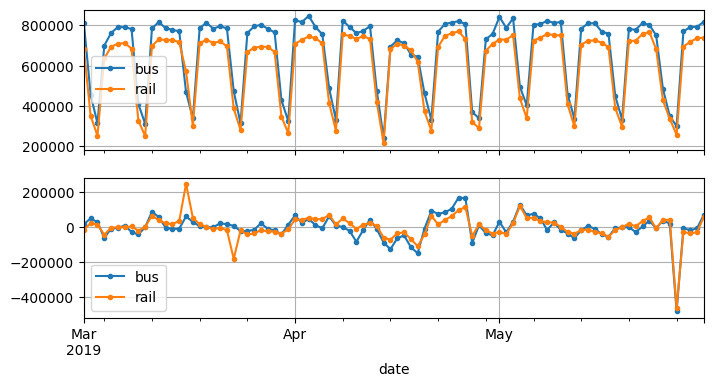

In [80]:
diff_7 = df[['bus', 'rail']].diff(7).loc['2019-03':'2019-05']

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8,4))
df.loc['2019-03':'2019-05'].plot(ax=axs[0], grid=True, marker='.')
diff_7.plot(ax=axs[1], grid=True, marker='.')

In [83]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

In [69]:
df[['bus', 'rail']].diff(2)

,bus,rail
date,,
2001-01-01,NaN,NaN
2001-01-02,NaN,NaN
2001-01-03,527731.0,409977.0
2001-01-04,89194.0,48059.0
2001-01-05,65503.0,21485.0
...,...,...
2021-11-26,-101561.0,-68188.0
2021-11-27,101159.0,83957.0
2021-11-28,-72883.0,-41864.0
